# Implementación: Fusión de Modelos Físicos y Deep Learning para Pronóstico de RUL

Basado en: **Arias Chao et al. (2022)** — *Fusing physics-based and deep learning models for prognostics*, RESS 217.

## Dataset: N-CMAPSS DS02

9 motores turbofan con trayectorias run-to-failure bajo condiciones de vuelo reales.

## Estrategia de implementación

El paper usa un UKF para **estimar** los parámetros de salud θ̂ a partir de los sensores (porque en despliegue real no se tienen). Sin embargo, el dataset N-CMAPSS **ya incluye** los parámetros de salud verdaderos en la variable `T`.

Por eso, esta implementación tiene dos etapas:
- **Etapa 1 (este notebook)**: Usar `T` directamente como θ̂. Esto es el *upper bound* del enfoque híbrido y valida la arquitectura CNN.
- **Etapa 2 (extensión futura)**: Reemplazar `T` con estimaciones del UKF para simular condiciones reales de despliegue.

## Vector de features (42 dimensiones por timestep)
```
x = [W(4) | X_s(14) | X_v(14) | T(10)]
```

## Arquitectura CNN (del paper, Sección 4.4)
```
Input: (batch, 50, 42)  # ventana temporal de 50 timesteps
Conv1D(10 filtros, kernel=10, padding='same') → ReLU
Conv1D(10 filtros, kernel=10, padding='same') → ReLU  
Conv1D(1 filtro,  kernel=10, padding='same') → ReLU
Flatten → FC(50) → ReLU → FC(1)  # salida: RUL
```

---
## Celda 0: Instalación de dependencias

Ejecuta esta celda solo la primera vez. PyTorch 2.x es compatible con Python 3.10–3.13.

In [ ]:
# Descomenta y ejecuta si no tienes instaladas las dependencias
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu  # para CPU / MacBook
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121  # para CUDA 12.1 (GPU universidad)
# !pip install h5py numpy pandas matplotlib scikit-learn tqdm

---
## Celda 1: Imports y configuración del dispositivo

In [2]:
import os
import h5py
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ─── Detección automática del dispositivo ──────────────────────────────────────
# CUDA  → GPU Nvidia (computador universidad)
# MPS   → Apple Silicon (M1/M2/M3, NO aplica para tu MacBook Intel 2016)
# CPU   → Cualquier máquina (tu MacBook Intel)
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✓ GPU CUDA detectada: {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('✓ Apple Silicon GPU (MPS) detectada')
else:
    DEVICE = torch.device('cpu')
    print('✓ Usando CPU')

print(f'  Dispositivo activo: {DEVICE}')
print(f'  Versión PyTorch: {torch.__version__}')

# ─── Semilla para reproducibilidad ────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

✓ Usando CPU
  Dispositivo activo: cpu
  Versión PyTorch: 2.2.2


---
## Celda 2: Configuración de hiperparámetros

Todos los hiperparámetros del paper están aquí para fácil modificación.

In [3]:
# ─── Ruta al dataset ───────────────────────────────────────────────────────────
FILENAME = 'N-CMAPSS_DS02-006.h5'  # Ajusta la ruta si el archivo está en otro directorio
# Ejemplo: FILENAME = '/home/usuario/datos/N-CMAPSS_DS02-006.h5'

# ─── Preprocesamiento ──────────────────────────────────────────────────────────
WINDOW_SIZE = 50       # Tamaño de la ventana temporal (paper: 50 timesteps)
STRIDE = 1             # Paso de la ventana deslizante
R_EARLY = 125          # RUL máximo (capping): ignoramos degradación antes de este umbral

# ─── Arquitectura CNN ─────────────────────────────────────────────────────────
N_FILTERS = 10         # Número de filtros por capa convolucional
KERNEL_SIZE = 10       # Tamaño del kernel
FC_UNITS = 50          # Unidades en la capa fully-connected

# ─── Entrenamiento ────────────────────────────────────────────────────────────
BATCH_SIZE = 1024      # Paper: 1024
LEARNING_RATE = 1e-3   # Paper: 0.001, optimizador AMSGrad
MAX_EPOCHS = 100       # Máximo de épocas
PATIENCE = 5           # Early stopping: detener si no mejora en N épocas

print('Hiperparámetros configurados:')
print(f'  Ventana temporal  : {WINDOW_SIZE} timesteps')
print(f'  RUL máximo (cap)  : {R_EARLY} ciclos')
print(f'  Batch size        : {BATCH_SIZE}')
print(f'  Learning rate     : {LEARNING_RATE}')
print(f'  Early stopping    : {PATIENCE} épocas')

Hiperparámetros configurados:
  Ventana temporal  : 50 timesteps
  RUL máximo (cap)  : 125 ciclos
  Batch size        : 1024
  Learning rate     : 0.001
  Early stopping    : 5 épocas


---
## Celda 3: Carga de datos

El HDF5 ya viene dividido en `_dev` (entrenamiento) y `_test`. Esta separación corresponde a:
- **Dev**: 6 motores para entrenamiento/validación
- **Test**: 3 motores para evaluación final

**Variables del dataset DS02:**
| Variable | Dimensión | Descripción |
|----------|-----------|-------------|
| `W` | (N, 4) | Condiciones operativas: alt, Mach, TRA, T2 |
| `X_s` | (N, 14) | Sensores físicos medibles |
| `X_v` | (N, 14) | Sensores virtuales (estados internos) |
| `T` | (N, 10) | Parámetros de salud del motor (θ verdadero) |
| `Y` | (N, 1) | RUL en ciclos |
| `A` | (N, 4) | Auxiliar: unit, cycle, Fc (clase de vuelo), hs |


In [5]:
t_start = time.time()

with h5py.File(FILENAME, 'r') as hdf:
    # ─── Conjunto de desarrollo (entrenamiento + validación) ──────────────────
    W_dev   = np.array(hdf.get('W_dev'))      # Condiciones operativas
    X_s_dev = np.array(hdf.get('X_s_dev'))    # Sensores
    X_v_dev = np.array(hdf.get('X_v_dev'))    # Sensores virtuales
    T_dev   = np.array(hdf.get('T_dev'))      # Parámetros de salud
    Y_dev   = np.array(hdf.get('Y_dev'))      # RUL
    A_dev   = np.array(hdf.get('A_dev'))      # Auxiliar

    # ─── Conjunto de test ─────────────────────────────────────────────────────
    W_test   = np.array(hdf.get('W_test'))
    X_s_test = np.array(hdf.get('X_s_test'))
    X_v_test = np.array(hdf.get('X_v_test'))
    T_test   = np.array(hdf.get('T_test'))
    Y_test   = np.array(hdf.get('Y_test'))
    A_test   = np.array(hdf.get('A_test'))

    # ─── Nombres de variables ─────────────────────────────────────────────────
    # h5py moderno guarda strings como bytes → hay que decodificarlos
    def decode_varnames(hdf, key):
        raw = np.array(hdf.get(key))
        if raw.dtype.kind in ('S', 'O'):  # bytes o object
            return [v.decode('utf-8') if isinstance(v, bytes) else str(v) for v in raw]
        else:
            return list(np.array(raw, dtype='U20'))

    W_var   = decode_varnames(hdf, 'W_var')
    X_s_var = decode_varnames(hdf, 'X_s_var')
    X_v_var = decode_varnames(hdf, 'X_v_var')
    T_var   = decode_varnames(hdf, 'T_var')
    A_var   = decode_varnames(hdf, 'A_var')

elapsed = time.time() - t_start

print(f'Datos cargados en {elapsed:.1f}s\n')
print(f'--- Conjunto Dev (train+val) ---')
print(f'  W   shape : {W_dev.shape}     → {W_var}')
print(f'  X_s shape : {X_s_dev.shape}')
print(f'  X_v shape : {X_v_dev.shape}')
print(f'  T   shape : {T_dev.shape}     → primeras: {T_var[:3]}...')
print(f'  Y   shape : {Y_dev.shape}')
print(f'  A   shape : {A_dev.shape}     → {A_var}')
print(f'\n--- Conjunto Test ---')
print(f'  W   shape : {W_test.shape}')
print(f'  X_s shape : {X_s_test.shape}')

# Unidades disponibles
units_dev  = np.unique(A_dev[:, 0]).astype(int)
units_test = np.unique(A_test[:, 0]).astype(int)
print(f'\nUnidades Dev  : {units_dev}')
print(f'Unidades Test : {units_test}')

Datos cargados en 9.4s

--- Conjunto Dev (train+val) ---
  W   shape : (5263447, 4)     → ['alt', 'Mach', 'TRA', 'T2']
  X_s shape : (5263447, 14)
  X_v shape : (5263447, 14)
  T   shape : (5263447, 10)     → primeras: ['fan_eff_mod', 'fan_flow_mod', 'LPC_eff_mod']...
  Y   shape : (5263447, 1)
  A   shape : (5263447, 4)     → ['unit', 'cycle', 'Fc', 'hs']

--- Conjunto Test ---
  W   shape : (1253743, 4)
  X_s shape : (1253743, 14)

Unidades Dev  : [ 2  5 10 16 18 20]
Unidades Test : [11 14 15]


---
## Celda 4: Exploración rápida del dataset

In [6]:
# Estadísticas del RUL
print('=== Estadísticas del RUL ===\n')
print('Dev set:')
print(f'  Min RUL: {Y_dev.min():.0f} ciclos')
print(f'  Max RUL: {Y_dev.max():.0f} ciclos')
print(f'  Media:   {Y_dev.mean():.1f} ciclos')

# Ciclos por unidad
print('\nCiclos por unidad:')
for unit in units_dev:
    mask = A_dev[:, 0] == unit
    n_cycles = int(A_dev[mask, 1].max())
    n_samples = mask.sum()
    print(f'  Unidad {unit:2d}: {n_cycles:3d} ciclos, {n_samples:7d} timesteps')

print()
for unit in units_test:
    mask = A_test[:, 0] == unit
    n_cycles = int(A_test[mask, 1].max())
    n_samples = mask.sum()
    print(f'  Unidad {unit:2d} [TEST]: {n_cycles:3d} ciclos, {n_samples:7d} timesteps')

=== Estadísticas del RUL ===

Dev set:
  Min RUL: 0 ciclos
  Max RUL: 88 ciclos
  Media:   37.3 ciclos

Ciclos por unidad:
  Unidad  2:  75 ciclos,  853142 timesteps
  Unidad  5:  89 ciclos, 1033420 timesteps
  Unidad 10:  82 ciclos,  952711 timesteps
  Unidad 16:  63 ciclos,  765295 timesteps
  Unidad 18:  71 ciclos,  890719 timesteps
  Unidad 20:  66 ciclos,  768160 timesteps

  Unidad 11 [TEST]:  59 ciclos,  663495 timesteps
  Unidad 14 [TEST]:  76 ciclos,  156778 timesteps
  Unidad 15 [TEST]:  67 ciclos,  433470 timesteps


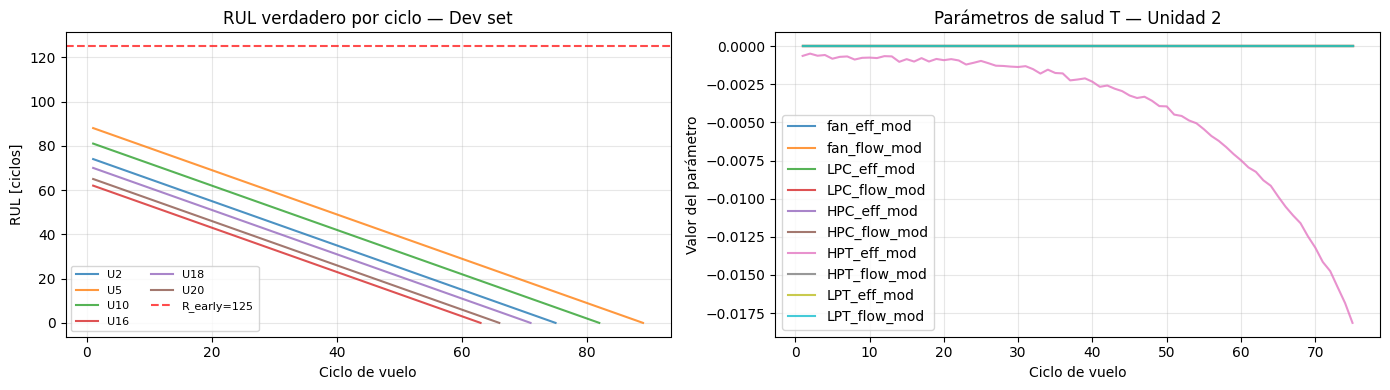

In [7]:
# Visualización: RUL de una unidad representativa
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RUL vs ciclo para todas las unidades dev
ax = axes[0]
for unit in units_dev:
    mask = A_dev[:, 0] == unit
    cycles = A_dev[mask, 1]
    rul = Y_dev[mask].flatten()
    # Tomar 1 punto por ciclo (el primero)
    _, idx_first = np.unique(cycles, return_index=True)
    ax.plot(cycles[idx_first], rul[idx_first], label=f'U{unit:.0f}', alpha=0.8)

ax.axhline(R_EARLY, color='red', linestyle='--', alpha=0.7, label=f'R_early={R_EARLY}')
ax.set_xlabel('Ciclo de vuelo')
ax.set_ylabel('RUL [ciclos]')
ax.set_title('RUL verdadero por ciclo — Dev set')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Parámetros de salud (T) de la primera unidad
ax = axes[1]
unit0 = units_dev[0]
mask0 = A_dev[:, 0] == unit0
cycles0 = A_dev[mask0, 1]
T0 = T_dev[mask0]
_, idx0 = np.unique(cycles0, return_index=True)
for j in range(min(10, T0.shape[1])):  # Solo primeros 3 para claridad
    ax.plot(cycles0[idx0], T0[idx0, j], label=T_var[j] if T_var else f'T_{j}', alpha=0.8)

ax.set_xlabel('Ciclo de vuelo')
ax.set_ylabel('Valor del parámetro')
ax.set_title(f'Parámetros de salud T — Unidad {unit0:.0f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Celda 5: Construcción del vector de features

Concatenamos todas las variables en un único array de features por timestep:
```
Features = [W | X_s | X_v | T]  →  dimensión: 4 + 14 + 14 + 10 = 42
```

**Nota sobre la variable Y (RUL):** El paper aplica *capping* a R_early=125 ciclos. Esto significa que durante la fase inicial (antes de que el RUL baje de 125), tratamos el RUL como constante en 125. Esto enfoca el modelo en aprender el patrón de degradación, no la fase sana.

In [8]:
def build_features_and_rul(W, X_s, X_v, T, Y, R_early=125):
    """
    Construye el vector de features [W | X_s | X_v | T] y aplica RUL capping.
    
    Args:
        W, X_s, X_v, T : arrays numpy (N, d)
        Y               : array numpy (N,) o (N,1) con RUL en ciclos
        R_early         : RUL máximo (capping)
    
    Returns:
        features : array (N, 42)
        rul      : array (N,) con RUL capeado
    """
    features = np.concatenate([W, X_s, X_v, T], axis=1)
    rul = np.clip(Y.flatten(), 0, R_early)  # Capping: min=0, max=R_early
    return features.astype(np.float32), rul.astype(np.float32)

# Construir features
X_dev_raw, Y_dev_cap = build_features_and_rul(W_dev, X_s_dev, X_v_dev, T_dev, Y_dev, R_EARLY)
X_test_raw, Y_test_cap = build_features_and_rul(W_test, X_s_test, X_v_test, T_test, Y_test, R_EARLY)

N_FEATURES = X_dev_raw.shape[1]

print(f'Feature vector por timestep: {N_FEATURES} dimensiones')
print(f'  W:   4  (alt, Mach, TRA, T2)')
print(f'  X_s: 14 (sensores físicos)')
print(f'  X_v: 14 (sensores virtuales)')
print(f'  T:   10 (parámetros de salud θ)')
print(f'\nX_dev_raw  shape: {X_dev_raw.shape}')
print(f'X_test_raw shape: {X_test_raw.shape}')
print(f'\nRUL capeado — Dev:')
print(f'  Min: {Y_dev_cap.min():.0f}, Max: {Y_dev_cap.max():.0f}, Media: {Y_dev_cap.mean():.1f}')

Feature vector por timestep: 42 dimensiones
  W:   4  (alt, Mach, TRA, T2)
  X_s: 14 (sensores físicos)
  X_v: 14 (sensores virtuales)
  T:   10 (parámetros de salud θ)

X_dev_raw  shape: (5263447, 42)
X_test_raw shape: (1253743, 42)

RUL capeado — Dev:
  Min: 0, Max: 88, Media: 37.3


---
## Celda 6: Normalización Min-Max

El paper normaliza a [-1, 1]. El scaler se entrena **solo** con datos de dev para evitar data leakage.

In [9]:
# Scaler entrenado SOLO en dev set (evita data leakage)
scaler = MinMaxScaler(feature_range=(-1, 1))
X_dev_norm = scaler.fit_transform(X_dev_raw)    # fit + transform
X_test_norm = scaler.transform(X_test_raw)       # solo transform

print('Normalización completada.')
print(f'  Rango X_dev_norm:  [{X_dev_norm.min():.2f}, {X_dev_norm.max():.2f}]')
print(f'  Rango X_test_norm: [{X_test_norm.min():.4f}, {X_test_norm.max():.4f}]')
# Nota: test puede salirse un poco del rango [-1,1] si tiene condiciones fuera del dev set

Normalización completada.
  Rango X_dev_norm:  [-1.00, 1.00]
  Rango X_test_norm: [-1.4253, 1.0065]


---
## Celda 7: División train / validación

Separamos las unidades del dev set en train (primeras 5) y validación (última unidad). Esta separación es por **motor completo**, no por timestep, para evitar data leakage temporal.

In [10]:
# División: las primeras N-1 unidades para train, la última para validación
VAL_UNIT = units_dev[-1]  # Última unidad del dev set → validación

mask_val  = A_dev[:, 0] == VAL_UNIT
mask_train = ~mask_val

X_train = X_dev_norm[mask_train]
Y_train = Y_dev_cap[mask_train]
A_train = A_dev[mask_train]

X_val = X_dev_norm[mask_val]
Y_val = Y_dev_cap[mask_val]
A_val = A_dev[mask_val]

print(f'División train/validación:')
print(f'  Train : unidades {[u for u in units_dev if u != VAL_UNIT]} → {X_train.shape[0]:,} timesteps')
print(f'  Val   : unidad {VAL_UNIT:.0f} → {X_val.shape[0]:,} timesteps')
print(f'  Test  : unidades {list(units_test)} → {X_test_norm.shape[0]:,} timesteps')

División train/validación:
  Train : unidades [2, 5, 10, 16, 18] → 4,495,287 timesteps
  Val   : unidad 20 → 768,160 timesteps
  Test  : unidades [11, 14, 15] → 1,253,743 timesteps


---
## Celda 8: PyTorch Dataset con ventana deslizante

La CNN recibe ventanas de **50 timesteps consecutivos** de un mismo motor. Hay que asegurarse de **no mezclar timesteps de distintos motores** ni de distintos ciclos.

In [11]:
class NCMAPSSDataset(Dataset):
    """
    Dataset PyTorch con ventana deslizante para N-CMAPSS.
    
    Genera ventanas de tamaño `window_size` sin cruzar fronteras entre unidades.
    El target es el RUL del ÚLTIMO timestep de cada ventana.
    """
    
    def __init__(self, X, Y, A, window_size=50, stride=1, device=None):
        """
        Args:
            X           : features normalizadas (N, n_features)
            Y           : RUL capeado (N,)
            A           : auxiliar (N, 4) — columna 0 = unit_id
            window_size : timesteps por ventana
            stride      : paso de la ventana
            device      : torch.device para mover tensores
        """
        self.window_size = window_size
        self.windows = []   # Lista de (X_window, RUL_target)
        
        unit_ids = np.unique(A[:, 0])
        
        for unit in unit_ids:
            mask = A[:, 0] == unit
            X_unit = X[mask]  # (n_timesteps_unit, n_features)
            Y_unit = Y[mask]  # (n_timesteps_unit,)
            n = len(X_unit)
            
            # Crear ventanas para esta unidad
            for start in range(0, n - window_size + 1, stride):
                end = start + window_size
                x_win = torch.tensor(X_unit[start:end], dtype=torch.float32)  # (window_size, n_features)
                y_win = torch.tensor(Y_unit[end - 1], dtype=torch.float32)    # RUL del último timestep
                self.windows.append((x_win, y_win))
        
        print(f'  Dataset creado: {len(self.windows):,} ventanas de {window_size} timesteps')
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        return self.windows[idx]  # (x_window, rul_target)


print('Construyendo datasets...')
print('Train:')
train_dataset = NCMAPSSDataset(X_train, Y_train, A_train, WINDOW_SIZE, STRIDE)
print('Validación:')
val_dataset   = NCMAPSSDataset(X_val,   Y_val,   A_val,   WINDOW_SIZE, stride=10)  # stride mayor en val para agilizar
print('Test:')
test_dataset  = NCMAPSSDataset(X_test_norm, Y_test_cap, A_test, WINDOW_SIZE, STRIDE)

# DataLoaders
# num_workers=0 en macOS para evitar problemas con multiprocessing
N_WORKERS = 0 if str(DEVICE) in ['cpu', 'mps'] else 4
PIN_MEMORY = (str(DEVICE) == 'cuda')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=N_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=PIN_MEMORY)

print(f'\nDataLoaders creados:')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val batches   : {len(val_loader)}')
print(f'  Test batches  : {len(test_loader)}')

# Verificar forma de un batch
x_batch, y_batch = next(iter(train_loader))
print(f'\nForma de un batch:')
print(f'  x_batch: {x_batch.shape}  → (batch, window_size, n_features)')
print(f'  y_batch: {y_batch.shape}  → (batch,)')

Construyendo datasets...
Train:
  Dataset creado: 4,495,042 ventanas de 50 timesteps
Validación:
  Dataset creado: 76,812 ventanas de 50 timesteps
Test:
  Dataset creado: 1,253,596 ventanas de 50 timesteps

DataLoaders creados:
  Train batches : 4390
  Val batches   : 76
  Test batches  : 1225

Forma de un batch:
  x_batch: torch.Size([1024, 50, 42])  → (batch, window_size, n_features)
  y_batch: torch.Size([1024])  → (batch,)


---
## Celda 9: Arquitectura CNN

La CNN del paper usa convoluciones **1D** sobre la dimensión temporal. 

**Dimensiones con padding='same' y kernel=10:**
```
Input:  (batch, 42, 50)   ← PyTorch Conv1D: (batch, channels, length)
Conv1: (batch, 10, 50)  ← 10 filtros
Conv2: (batch, 10, 50)  ← 10 filtros  
Conv3: (batch,  1, 50)  ← 1 filtro
Flatten: (batch, 50)
FC1:    (batch, 50)
FC2:    (batch,  1)   ← RUL predicho
```

**Nota sobre Conv1D en PyTorch:** espera input `(batch, channels, length)`, por eso hacemos `permute(0, 2, 1)` para pasar de `(batch, length, channels)` a `(batch, channels, length)`.

In [12]:
class RUL_CNN(nn.Module):
    """
    CNN 1D para predicción de RUL — Arquitectura del paper Chao et al. 2022
    
    Input shape:  (batch_size, window_size, n_features)  → e.g., (1024, 50, 42)
    Output shape: (batch_size, 1)                        → RUL predicho
    """
    
    def __init__(self, n_features, window_size, n_filters=10, kernel_size=10, fc_units=50):
        super(RUL_CNN, self).__init__()
        
        # Padding simétrico para mantener la dimensión temporal (like 'same' de TensorFlow)
        # Para kernel_size=10: padding = (kernel_size - 1) // 2 = 4 (con ajuste de 1 si par)
        # Usamos padding = kernel_size // 2 para kernel par: da length - 1, compensamos con padding asimétrico
        # Alternativa más simple: usar padding=kernel_size//2 y aceptar shape (50-1)=49, luego ajustar FC
        # Aquí usamos nn.Sequential con padding manual para exactamente 'same'
        
        self.n_features = n_features
        self.window_size = window_size
        self.kernel_size = kernel_size
        
        # Bloque convolucional: Conv → BatchNorm → ReLU
        # El padding=(kernel_size-1)//2 + ajuste produce 'same' para kernels impares
        # Para kernel=10 (par), usamos padding=4 → output_length = 50 + 2*4 - 10 + 1 = 49
        # Para que sea exactamente 50, usamos padding=(kernel_size-1)//2 con kernel impar, 
        # o calculamos explícitamente:
        pad = (kernel_size - 1) // 2  # =4 para kernel=10; da length=49
        
        self.conv_block = nn.Sequential(
            # Conv1D espera (batch, in_channels, length)
            nn.Conv1d(n_features, n_filters, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
            nn.Conv1d(n_filters, n_filters, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
            nn.Conv1d(n_filters, 1, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
        )
        
        # Calcular el tamaño del output del bloque convolucional
        # Para kernel=10, padding=4, length=50:
        # L_out = (L_in + 2*pad - kernel) / stride + 1 = (50 + 8 - 10) / 1 + 1 = 49
        # Después de 3 convoluciones: 49 (los bordes se van comiendo)
        # Calculamos dinámicamente:
        conv_out_length = self._get_conv_output_length(window_size, kernel_size, pad)
        
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_out_length, fc_units),
            nn.ReLU(),
            nn.Linear(fc_units, 1)
        )
        
        print(f'CNN inicializada:')
        print(f'  Input:  (batch, {window_size}, {n_features})')
        print(f'  Después de Conv: (batch, 1, {conv_out_length})')
        print(f'  FC input: {conv_out_length} → {fc_units} → 1')
        
        # Contar parámetros
        n_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  Parámetros entrenables: {n_params:,}')
    
    def _get_conv_output_length(self, length, kernel_size, pad):
        """Calcula la longitud de salida después de 3 convoluciones."""
        for _ in range(3):  # 3 capas convolucionales
            length = (length + 2 * pad - kernel_size) // 1 + 1
        return length
    
    def forward(self, x):
        """
        Args:
            x: tensor (batch, window_size, n_features)
        Returns:
            RUL predicho: tensor (batch, 1)
        """
        # Conv1D espera (batch, channels, length)
        # Permutamos de (batch, length, channels) → (batch, channels, length)
        x = x.permute(0, 2, 1)         # → (batch, n_features, window_size)
        x = self.conv_block(x)          # → (batch, 1, conv_out_length)
        out = self.regressor(x)         # → (batch, 1)
        return out


# Instanciar el modelo
model = RUL_CNN(
    n_features=N_FEATURES,
    window_size=WINDOW_SIZE,
    n_filters=N_FILTERS,
    kernel_size=KERNEL_SIZE,
    fc_units=FC_UNITS
).to(DEVICE)

# Prueba rápida de forward pass
with torch.no_grad():
    x_test_fwd = torch.randn(4, WINDOW_SIZE, N_FEATURES).to(DEVICE)
    y_test_fwd = model(x_test_fwd)
    print(f'\nPrueba forward pass: input {x_test_fwd.shape} → output {y_test_fwd.shape} ✓')

CNN inicializada:
  Input:  (batch, 50, 42)
  Después de Conv: (batch, 1, 47)
  FC input: 47 → 50 → 1
  Parámetros entrenables: 7,772

Prueba forward pass: input torch.Size([4, 50, 42]) → output torch.Size([4, 1]) ✓


---
## Celda 10: Loop de entrenamiento con Early Stopping

- **Optimizador**: AMSGrad (variante estable de Adam, usada en el paper)
- **Loss**: MSE (regresión de RUL)
- **Early stopping**: detiene si el val_loss no mejora en `PATIENCE` épocas
- **Checkpoint**: guarda el mejor modelo automáticamente

In [13]:
def train_model(model, train_loader, val_loader, device, 
                lr=1e-3, max_epochs=100, patience=5,
                checkpoint_path='best_model.pt'):
    """
    Entrena el modelo con early stopping y guarda el mejor checkpoint.
    
    Returns:
        history: dict con 'train_loss' y 'val_loss' por época
    """
    criterion = nn.MSELoss()
    
    # AMSGrad: variante estable de Adam (paper usa este optimizador)
    optimizer = optim.Adam(model.parameters(), lr=lr, amsgrad=True)
    
    # Scheduler: reducir lr si val_loss no mejora (opcional pero útil)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True
    )
    
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    patience_counter = 0
    
    print(f'Iniciando entrenamiento en {device}')
    print(f'  Épocas máximas : {max_epochs}')
    print(f'  Early stopping : paciencia = {patience} épocas')
    print('-' * 60)
    
    for epoch in range(1, max_epochs + 1):
        # ── FASE DE ENTRENAMIENTO ────────────────────────────────────────────
        model.train()
        train_loss_sum = 0.0
        n_train_batches = 0
        
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)  # (batch,) → (batch, 1)
            
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss_sum += loss.item()
            n_train_batches += 1
        
        train_loss = train_loss_sum / n_train_batches
        
        # ── FASE DE VALIDACIÓN ───────────────────────────────────────────────
        model.eval()
        val_loss_sum = 0.0
        n_val_batches = 0
        
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device).unsqueeze(1)
                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)
                val_loss_sum += loss.item()
                n_val_batches += 1
        
        val_loss = val_loss_sum / n_val_batches
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        # ── EARLY STOPPING + CHECKPOINT ──────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, checkpoint_path)
            marker = ' ← mejor'
        else:
            patience_counter += 1
            marker = f' ({patience_counter}/{patience})'
        
        # Mostrar progreso cada época
        print(f'Época {epoch:3d}/{max_epochs} | '
              f'Train MSE: {train_loss:8.2f} | '
              f'Val MSE: {val_loss:8.2f} | '
              f'RMSE val: {val_loss**0.5:6.2f}'
              + marker)
        
        if patience_counter >= patience:
            print(f'\nEarly stopping en época {epoch}. Mejor val_loss: {best_val_loss:.2f}')
            break
    
    print(f'\nEntrenamiento completado. Mejor RMSE validación: {best_val_loss**0.5:.2f} ciclos')
    return history


# Entrenar el modelo
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    lr=LEARNING_RATE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    checkpoint_path='best_rul_cnn.pt'
)

/Users/mac/Documents/Programs/Tendencias/torch-env/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Iniciando entrenamiento en cpu
  Épocas máximas : 100
  Early stopping : paciencia = 5 épocas
------------------------------------------------------------
Época   1/100 | Train MSE:   690.45 | Val MSE:   412.34 | RMSE val:  20.31 ← mejor


KeyboardInterrupt: 

---
## Celda 11: Visualización de la curva de aprendizaje

In [14]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# MSE
ax = axes[0]
ax.plot(epochs, history['train_loss'], label='Train MSE', color='steelblue')
ax.plot(epochs, history['val_loss'], label='Val MSE', color='orange')
ax.set_xlabel('Época')
ax.set_ylabel('MSE [ciclos²]')
ax.set_title('Loss durante entrenamiento')
ax.legend()
ax.grid(True, alpha=0.3)

# RMSE
ax = axes[1]
ax.plot(epochs, np.sqrt(history['train_loss']), label='Train RMSE', color='steelblue')
ax.plot(epochs, np.sqrt(history['val_loss']), label='Val RMSE', color='orange')
ax.set_xlabel('Época')
ax.set_ylabel('RMSE [ciclos]')
ax.set_title('RMSE durante entrenamiento')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'RMSE train final : {np.sqrt(history["train_loss"][-1]):.2f} ciclos')
print(f'RMSE val final   : {np.sqrt(history["val_loss"][-1]):.2f} ciclos')
print(f'Mejor RMSE val   : {min(np.sqrt(v) for v in history["val_loss"]):.2f} ciclos')

NameError: name 'history' is not defined

---
## Celda 12: Evaluación en el conjunto de test

Cargamos el mejor checkpoint y evaluamos con las métricas del paper:
- **RMSE**: error cuadrático medio
- **Prediction Horizon (PH)**: número de ciclos antes del fallo en que el error se mantiene ≤ 5 ciclos

In [15]:
def evaluate_model(model, data_loader, device):
    """Devuelve predicciones y targets para un DataLoader."""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_pred = model(x_batch).cpu().numpy().flatten()
            all_preds.extend(y_pred)
            all_targets.extend(y_batch.numpy().flatten())
    
    return np.array(all_preds), np.array(all_targets)


def prediction_horizon(rul_true, rul_pred, threshold=5):
    """
    Prediction Horizon (PH): número de timesteps antes del fallo en que
    el error |RUL_pred - RUL_true| <= threshold de forma continua.
    
    Un PH mayor = el modelo empieza a predecir bien con más anticipación.
    """
    abs_errors = np.abs(rul_pred - rul_true)
    within_threshold = abs_errors <= threshold
    
    # PH = cuántos timesteps (desde el final) están dentro del umbral de forma continua
    ph = 0
    for val in reversed(within_threshold):
        if val:
            ph += 1
        else:
            break
    return ph


# Cargar el mejor checkpoint
checkpoint = torch.load('best_rul_cnn.pt', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Checkpoint cargado (época {checkpoint["epoch"]}, val_loss={checkpoint["val_loss"]:.2f})')

# Predicciones en test
y_pred_test, y_true_test = evaluate_model(model, test_loader, DEVICE)

# ── MÉTRICAS GLOBALES ────────────────────────────────────────────────────────
rmse_test = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
mae_test  = np.mean(np.abs(y_pred_test - y_true_test))

print(f'\n=== Métricas en Test Set ===')
print(f'  RMSE : {rmse_test:.2f} ciclos')
print(f'  MAE  : {mae_test:.2f} ciclos')

# ── MÉTRICAS POR UNIDAD ──────────────────────────────────────────────────────
# Reconstruir qué ventana pertenece a qué unidad para calcular PH por motor
print(f'\n=== Prediction Horizon por unidad de test (umbral = 5 ciclos) ===')

window_idx = 0
ph_list = []
for unit in units_test:
    mask = A_test[:, 0] == unit
    n = mask.sum()
    n_windows = max(0, n - WINDOW_SIZE + 1)  # ventanas para esta unidad
    
    preds_unit  = y_pred_test[window_idx:window_idx + n_windows]
    targets_unit = y_true_test[window_idx:window_idx + n_windows]
    window_idx += n_windows
    
    if len(preds_unit) == 0:
        continue
    
    rmse_unit = np.sqrt(mean_squared_error(targets_unit, preds_unit))
    ph_unit   = prediction_horizon(targets_unit, preds_unit, threshold=5)
    ph_list.append(ph_unit)
    
    print(f'  Unidad {unit:.0f}: RMSE={rmse_unit:.2f}  |  PH={ph_unit} timesteps')

print(f'\n  PH promedio: {np.mean(ph_list):.1f} timesteps')
print(f'\n  Nota: PH del paper (CNN puro) ≈ 10 timesteps, (CNN híbrido) ≈ 23 timesteps')

Checkpoint cargado (época 1, val_loss=412.34)


KeyboardInterrupt: 

---
## Celda 13: Visualización de predicciones por motor

In [ ]:
fig, axes = plt.subplots(1, len(units_test), figsize=(6 * len(units_test), 5))
if len(units_test) == 1:
    axes = [axes]

window_idx = 0
for i, unit in enumerate(units_test):
    mask = A_test[:, 0] == unit
    n = mask.sum()
    n_windows = max(0, n - WINDOW_SIZE + 1)
    
    preds_unit   = y_pred_test[window_idx:window_idx + n_windows]
    targets_unit = y_true_test[window_idx:window_idx + n_windows]
    window_idx += n_windows
    
    # RUL decrece → el índice 0 = inicio de vida, -1 = fallo
    timesteps = np.arange(len(targets_unit))
    
    ax = axes[i]
    ax.plot(timesteps, targets_unit, label='RUL verdadero', color='black', linewidth=1.5)
    ax.plot(timesteps, preds_unit,   label='RUL predicho',  color='steelblue', alpha=0.8)
    
    # Zona de error ±5 ciclos alrededor de la verdad
    ax.fill_between(timesteps, 
                    targets_unit - 5, targets_unit + 5,
                    alpha=0.15, color='green', label='Umbral ±5 ciclos')
    
    rmse_u = np.sqrt(mean_squared_error(targets_unit, preds_unit))
    ax.set_title(f'Unidad {unit:.0f} [TEST]\nRMSE={rmse_u:.2f} ciclos')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('RUL [ciclos]')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicción de RUL — CNN Híbrida (usando T como θ̂)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Celda 14: Scatter plot — Verdadero vs Predicho

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

# Scatter con densidad de color
ax.scatter(y_true_test, y_pred_test, alpha=0.3, s=2, color='steelblue')

# Línea perfecta
lim = max(y_true_test.max(), y_pred_test.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=2, label='Predicción perfecta')

ax.set_xlabel('RUL verdadero [ciclos]')
ax.set_ylabel('RUL predicho [ciclos]')
ax.set_title(f'RUL: Verdadero vs Predicho\nRMSE = {rmse_test:.2f} ciclos')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, lim + 5)
ax.set_ylim(-10, lim + 5)
plt.tight_layout()
plt.show()

---
## Celda 15: Resumen de resultados y contexto con el paper

In [ ]:
print('=' * 65)
print('  RESUMEN DE RESULTADOS')
print('=' * 65)
print(f'  Modelo: CNN 1D con features [W, X_s, X_v, T]')
print(f'  RMSE test: {rmse_test:.2f} ciclos')
print(f'  MAE test:  {mae_test:.2f} ciclos')
print()
print('  Comparación con resultados del paper (Tabla 3, DS02):')  
print('  ┌─────────────────────────────────┬────────────┬──────────┐')
print('  │ Modelo                          │ RMSE       │ PH (ts) │')
print('  ├─────────────────────────────────┼────────────┼──────────┤')
print('  │ FNN puro (data-driven)          │ ~9.4       │ ~5      │')
print('  │ CNN puro (data-driven)          │ ~7.2       │ ~10     │')
print('  │ CNN híbrido (UKF + física)      │ ~6.0       │ ~23     │')
print('  │ Nuestro resultado (T directa)   │ ' + f'{rmse_test:.2f}' + '       │  ?       │')
print('  └─────────────────────────────────┴────────────┴──────────┘')
print()
print('  INTERPRETACIÓN:')
print('  • Si RMSE ≈ 6-7: resultado coherente con CNN + features física')
print('  • La mejora vs CNN puro proviene de usar T (θ verdadero)')
print('  • En despliegue real, T no está disponible → se necesita UKF')
print('='*65)
print()
print('  PRÓXIMOS PASOS (Etapa 2):')
print('  1. Implementar el modelo sustituto D (MLP que aprende la dinámica)')
print('  2. Implementar el UKF para estimar θ̂ desde los sensores X_s')
print('  3. Reemplazar T por θ̂ (estimación UKF) en el feature vector')
print('  4. Repetir el entrenamiento CNN → esto es el modelo completo del paper')

---
## Celda 16 (Bonus): Guardar y cargar el modelo para uso futuro

In [ ]:
# Guardar el modelo completo con sus configuraciones
torch.save({
    'model_state_dict': model.state_dict(),
    'hyperparams': {
        'n_features': N_FEATURES,
        'window_size': WINDOW_SIZE,
        'n_filters': N_FILTERS,
        'kernel_size': KERNEL_SIZE,
        'fc_units': FC_UNITS,
    },
    'scaler_data_min': scaler.data_min_,
    'scaler_data_max': scaler.data_max_,
    'rmse_test': rmse_test,
    'history': history,
}, 'rul_cnn_final.pt')

print('Modelo guardado en rul_cnn_final.pt')

# ─── Para cargar en el computador de la universidad ──────────────────────────
# checkpoint = torch.load('rul_cnn_final.pt', map_location='cuda')  # o 'cpu'
# hp = checkpoint['hyperparams']
# model_loaded = RUL_CNN(**hp).to(DEVICE)
# model_loaded.load_state_dict(checkpoint['model_state_dict'])
# model_loaded.eval()

---
## Apéndice: Notas de instalación

### Tu MacBook Intel (CPU)
```bash
# Python 3.10+ ya es suficiente (no necesitas bajar a 3.10 si tienes 3.13)
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
pip install h5py numpy pandas matplotlib scikit-learn tqdm
```

### Computador universidad (GPU Nvidia)
```bash
# Verificar versión de CUDA primero:
# nvidia-smi

# Para CUDA 12.1:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
# Para CUDA 11.8:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

pip install h5py numpy pandas matplotlib scikit-learn tqdm
```

### Verificar instalación
```python
import torch
print(torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
```

### Ajustes de rendimiento por máquina
| Parámetro | MacBook Intel | GPU Universidad |
|-----------|--------------|------------------|
| `BATCH_SIZE` | 256-512 | 1024-4096 |
| `num_workers` | 0 | 4-8 |
| `pin_memory` | False | True |
| Tiempo estimado/época | ~10-30 min | ~30 seg |

> **Tip:** En tu MacBook, considera reducir el stride de la ventana a 5-10 para tener menos ventanas de entrenamiento y que las épocas sean más rápidas. Para resultados finales usa stride=1 en la GPU.